> **English version.** This notebook is an English translation of the original Persian notebook [`part3_price_and_driver_match_prediction_FA.ipynb`](part3_price_and_driver_match_prediction_FA.ipynb). Markdown text has been translated; the code logic is unchanged. There are two code changes: the data path now points to the shared file `../data/data.csv`, and the classification metrics used in section 2 (`accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `roc_auc_score`, `confusion_matrix`) are now imported in the first code cell, so the notebook runs from top to bottom.

## Part 3: Behaviour Prediction (linear and logistic regression)
In this part:
1) We predict the trip price with linear regression and report the evaluation metrics.
2) With logistic regression we predict whether a driver accepts the trip or not (status != 4).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix  # added: used in section 2
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression

DATA_PATH = "../data/data.csv"

In [2]:
df = pd.read_csv(DATA_PATH)

# Parse time columns
df['price_check_time'] = pd.to_datetime(df['price_check_time'], format='%m-%d-%y %H:%M', errors='coerce')
df['req_time'] = pd.to_datetime(df['req_time'], format='%m-%d-%y %H:%M', errors='coerce')

# Feature engineering
df['has_request'] = df['req_time'].notna()
df['hour'] = df['req_time'].dt.hour
df['distance_km'] = df['distance'] / 1000.0
df['price_after_discount'] = df['price'] - df['subsidy']
df['discount_ratio'] = df['subsidy'] / df['price']
df['price_per_km'] = df['price_after_discount'] / df['distance_km']

# Keep only actual ride requests (req_time not null)
df_req = df[df['has_request']].copy()

# Basic validity filters 
num_cols = ['price','subsidy','distance','expected_duration']
for c in num_cols:
    df_req = df_req[df_req[c].notna()]
df_req = df_req[(df_req['price']>0) & (df_req['distance']>0) & (df_req['expected_duration']>0) & (df_req['subsidy']>=0)]

# IQR outlier removal on key numeric columns
def iqr_mask(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - k*iqr, q3 + k*iqr
    return (s>=lo) & (s<=hi)

mask = (
    iqr_mask(df_req['price']) &
    iqr_mask(df_req['distance']) &
    iqr_mask(df_req['expected_duration']) &
    iqr_mask(df_req['price_per_km'])
)
df_clean = df_req[mask].copy()

print("Raw rows:", df.shape[0])
print("Ride requests:", df_req.shape[0])
print("Cleaned requests:", df_clean.shape[0])
df_clean.head()

Raw rows: 26768
Ride requests: 16253
Cleaned requests: 13974


,price_check_time,passenger,origin,destination,price,subsidy,distance,expected_duration,req_time,driver,status,has_request,hour,distance_km,price_after_discount,discount_ratio,price_per_km
17,2021-01-03 12:28:00,74,0,0,50000,10000,2912.0,8.0,2021-01-03 12:36:00,NaN,2.0,True,12.0,2.912,40000,0.200000,13736.263736
26,2021-01-06 07:57:00,130,0,0,65000,10000,2466.0,4.0,2021-01-06 08:00:00,NaN,2.0,True,8.0,2.466,55000,0.153846,22303.325223
28,2021-01-07 11:51:00,147,0,0,60000,10000,3337.0,7.0,2021-01-07 12:00:00,NaN,4.0,True,12.0,3.337,50000,0.166667,14983.518130
38,2021-01-06 09:21:00,189,0,0,85000,0,6282.0,10.0,2021-01-06 09:27:00,NaN,2.0,True,9.0,6.282,85000,0.000000,13530.722700
39,2021-01-07 12:34:00,189,0,0,65000,0,6898.0,11.0,2021-01-07 12:36:00,NaN,2.0,True,12.0,6.898,65000,0.000000,9423.021166


### 1) Linear regression to predict price

In [3]:
reg = df_clean.copy()
reg['hour'] = reg['hour'].astype(int)

X = reg[['hour','distance_km','expected_duration','subsidy','origin','destination']]
y = reg['price']

num_features = ['hour','distance_km','expected_duration','subsidy']
cat_features = ['origin','destination']

preprocess = ColumnTransformer([
    ('num', Pipeline([('scaler', StandardScaler())]), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

model = Pipeline([
    ('prep', preprocess),
    ('lr', LinearRegression())
])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = (np.abs((y_test - y_pred) / y_test)).mean() * 100
r2 = r2_score(y_test, y_pred)

print("\n[Linear Regression Metrics]")
print(f"MAE={mae:.0f}, RMSE={rmse:.0f}, MAPE={mape:.2f}%, R2={r2:.3f}")


[Linear Regression Metrics]
MAE=6824, RMSE=8835, MAPE=11.54%, R2=0.594


In [4]:
# Compare one sample
sample_idx = y_test.index[0]
sample_X = X.loc[[sample_idx]]
real = float(y.loc[sample_idx])
pred = float(model.predict(sample_X)[0])
abs_diff = abs(real - pred)
pct_diff = abs_diff / real * 100

print("Sample record index:", sample_idx)
print(f"Real price={real:.0f}, Predicted={pred:.0f}, Abs error={abs_diff:.0f}, Percent error={pct_diff:.1f}%")
print(f"Is sample error <= MAE? {abs_diff <= mae}")

Sample record index: 17239
Real price=50000, Predicted=59891, Abs error=9891, Percent error=19.8%
Is sample error <= MAE? False


,feature,coef,abs
1,distance_km,5467.272655,5467.272655
2,expected_duration,4284.499584,4284.499584
3,subsidy,2549.206395,2549.206395
7,origin_3,-2020.109809,2020.109809
13,destination_4,-1880.785549,1880.785549
10,destination_1,1358.430751,1358.430751
4,origin_0,1310.714358,1310.714358
0,hour,-1036.370744,1036.370744
5,origin_1,975.268949,975.268949
11,destination_2,409.340998,409.340998


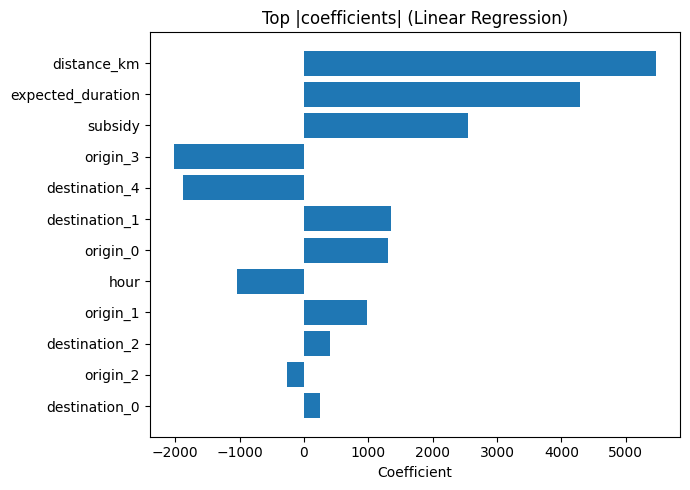

In [5]:
# Feature importance via coefficients
ohe = model.named_steps['prep'].named_transformers_['cat']
cat_names = list(ohe.get_feature_names_out(cat_features))
feature_names = num_features + cat_names
coefs = model.named_steps['lr'].coef_

coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefs})
coef_df['abs'] = coef_df['coef'].abs()
display(coef_df.sort_values('abs', ascending=False).head(15))

top = coef_df.sort_values('abs', ascending=False).head(12).sort_values('abs')
plt.figure(figsize=(7,5))
plt.barh(top['feature'], top['coef'])
plt.xlabel('Coefficient')
plt.title('Top |coefficients| (Linear Regression)')
plt.tight_layout()
plt.show()

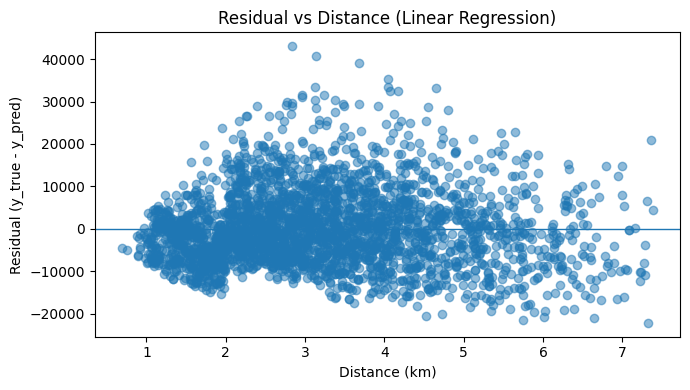

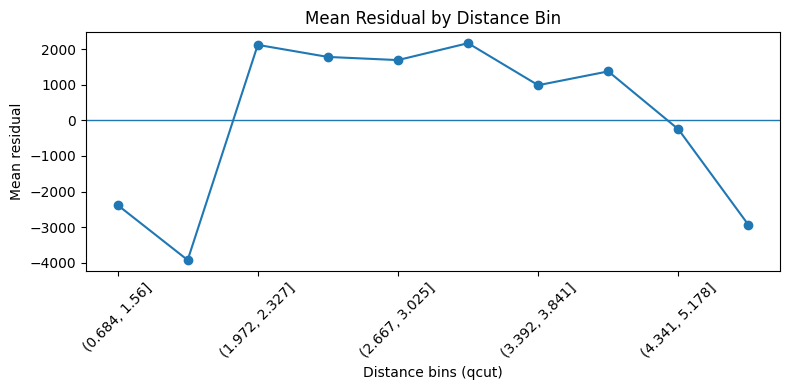

In [6]:
# Residual vs distance plot (as requested)
# Check if model behaves differently for long-distance trips
residuals = y_test - y_pred
dist_test = X_test["distance_km"]

plt.figure(figsize=(7, 4))
plt.scatter(dist_test, residuals, alpha=0.5)
plt.axhline(0, linewidth=1)
plt.xlabel("Distance (km)")
plt.ylabel("Residual (y_true - y_pred)")
plt.title("Residual vs Distance (Linear Regression)")
plt.tight_layout()
plt.show()

# Optional: residual trend by distance bins 
bins = pd.qcut(dist_test, q=10, duplicates="drop")

res_by_bin = (
    residuals
    .groupby(bins, observed=False)
    .mean()
)

plt.figure(figsize=(8, 4))
res_by_bin.plot(marker="o")
plt.axhline(0, linewidth=1)
plt.xticks(rotation=45)
plt.xlabel("Distance bins (qcut)")
plt.ylabel("Mean residual")
plt.title("Mean Residual by Distance Bin")
plt.tight_layout()
plt.show()

### 2) Logistic regression to predict driver acceptance
Target: `accepted_by_driver = 1` if `status != 4` (a driver was found), and 0 otherwise.


[Logistic Regression Metrics]
Accuracy=0.575, Precision=0.981, Recall=0.578, F1=0.727, ROC-AUC=0.509

Confusion matrix:
 [[  24   31]
 [1157 1583]]


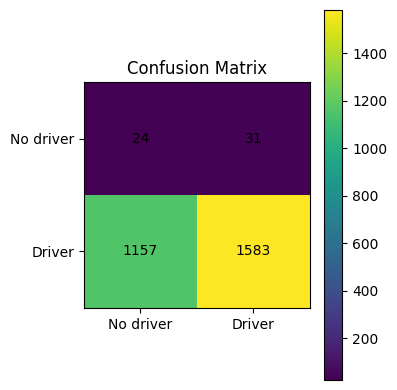


[Logistic coefficients (top by |coef|)]


,feature,coef,odds_ratio,abs
12,destination_4,-0.370358,0.690487,0.370358
7,origin_4,-0.236154,0.789659,0.236154
8,destination_0,0.128026,1.136582,0.128026
11,destination_3,0.112583,1.119165,0.112583
5,origin_2,0.111892,1.118392,0.111892
0,hour,-0.111884,0.894148,0.111884
9,destination_1,0.096314,1.101105,0.096314
10,destination_2,-0.064645,0.937400,0.064645
4,origin_1,0.043873,1.044850,0.043873
1,distance_km,-0.035408,0.965211,0.035408



[Interpretation for numeric features]


,feature,coef,odds_ratio
0,hour,-0.111884,0.894148
1,distance_km,-0.035408,0.965211
2,subsidy,0.022316,1.022567



[Conclusion based on logistic coefficients]
subsidy coef = 0.022  (odds ratio=1.023) -> increases probability of driver acceptance (per 1 std change).
distance_km coef = -0.035  (odds ratio=0.965) -> decreases probability of driver acceptance (per 1 std change).


In [7]:
# target = accepted_by_driver = 1 if status != 4 (a driver was found)
clf = df_clean[df_clean["status"].isin([1, 2, 3, 4])].dropna(
    subset=["hour", "distance_km", "subsidy", "origin", "destination", "status"]
).copy()

clf["hour"] = clf["hour"].astype(int)
clf["accepted_by_driver"] = (clf["status"] != 4).astype(int)

X = clf[["hour", "distance_km", "subsidy", "origin", "destination"]]
y = clf["accepted_by_driver"]

num = ["hour", "distance_km", "subsidy"]
cat = ["origin", "destination"]

pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("scaler", StandardScaler())]), num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
    ]
)

logit_model = Pipeline(
    steps=[
        ("prep", pre),
        ("logreg", LogisticRegression(max_iter=2000, class_weight="balanced")),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

logit_model.fit(X_train, y_train)

proba = logit_model.predict_proba(X_test)[:, 1]
yhat = logit_model.predict(X_test)

acc = accuracy_score(y_test, yhat)
prec = precision_score(y_test, yhat, zero_division=0)
rec = recall_score(y_test, yhat)
f1 = f1_score(y_test, yhat)
auc = roc_auc_score(y_test, proba)

print("\n[Logistic Regression Metrics]")
print(f"Accuracy={acc:.3f}, Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}, ROC-AUC={auc:.3f}")

cm = confusion_matrix(y_test, yhat)
print("\nConfusion matrix:\n", cm)

plt.figure(figsize=(4, 4))
plt.imshow(cm)
plt.xticks([0, 1], ["No driver", "Driver"])
plt.yticks([0, 1], ["No driver", "Driver"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, int(cm[i, j]), ha="center", va="center")
plt.title("Confusion Matrix")
plt.colorbar()
plt.tight_layout()
plt.show()


# Coefficient interpretation
# Since we used StandardScaler on numeric features, coefficients are per 1 std change.
# show sign + odds ratio for numeric features (hour, distance_km, subsidy).
prep_fitted = logit_model.named_steps["prep"]
logreg = logit_model.named_steps["logreg"]

ohe2 = prep_fitted.named_transformers_["cat"]
cat_names2 = list(ohe2.get_feature_names_out(cat))
all_feature_names = num + cat_names2

coef = logreg.coef_.ravel()
coef_df2 = pd.DataFrame({"feature": all_feature_names, "coef": coef})
coef_df2["odds_ratio"] = np.exp(coef_df2["coef"])

print("\n[Logistic coefficients (top by |coef|)]")
display(coef_df2.assign(abs=np.abs(coef_df2["coef"])).sort_values("abs", ascending=False).head(15))

# Focus only on numeric features for the exact question: subsidy and distance effect
num_effects = coef_df2[coef_df2["feature"].isin(num)].copy()
print("\n[Interpretation for numeric features]")
display(num_effects)

# Simple conclusion text inside code output:
subsidy_row = num_effects[num_effects["feature"] == "subsidy"].iloc[0]
dist_row = num_effects[num_effects["feature"] == "distance_km"].iloc[0]

print("\n[Conclusion based on logistic coefficients]")
print(
    f"subsidy coef = {subsidy_row['coef']:.3f}  (odds ratio={subsidy_row['odds_ratio']:.3f}) -> "
    + ("increases" if subsidy_row["coef"] > 0 else "decreases")
    + " probability of driver acceptance (per 1 std change)."
)
print(
    f"distance_km coef = {dist_row['coef']:.3f}  (odds ratio={dist_row['odds_ratio']:.3f}) -> "
    + ("increases" if dist_row["coef"] > 0 else "decreases")
    + " probability of driver acceptance (per 1 std change)."
)